# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Daffa Aufa Afif | 5054251022 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
https://www.kaggle.com/datasets/abbas829/bankruptcy

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [ ]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import kagglehub
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
path = kagglehub.dataset_download("abbas829/bankruptcy")

os.makedirs('/data', exist_ok=True)
for item in os.listdir(path):
    s = os.path.join(path, item)
    d = os.path.join('/data', item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)

print("Dataset moved to /data successfully!")


Using Colab cache for faster access to the 'bankruptcy' dataset.
Dataset moved to /data successfully!


In [ ]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.

df = pd.read_csv('/data/bankruptcy.csv')
print("----------5 Data awal----------")
print(df.head())
print("----------info data----------")
print(df.info())
print("----------deskripsi data----------")
print(df.describe())
print("----------jumlah missing value----------")
print(df.isnull().sum())
print("----------jumlah data----------")
print(df.shape)


----------5 Data awal----------
   Bankrupt?   ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594          
1          1                                           0.464291          
2          1                                           0.426071          
3          1                                           0.399844          
4          1                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                                           0.472295    
3                 

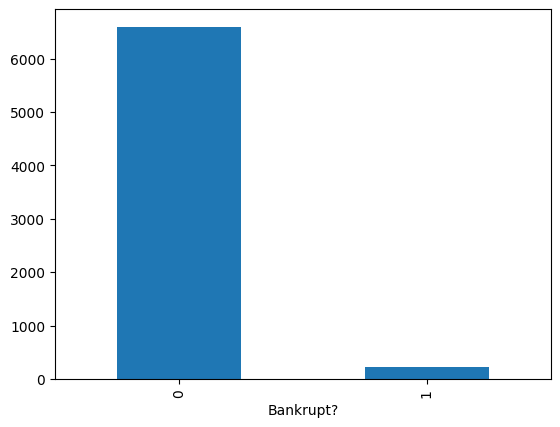

In [ ]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
target = df['Bankrupt?']
target.value_counts().plot(kind='bar')
plt.show()

Sangat imbalanced

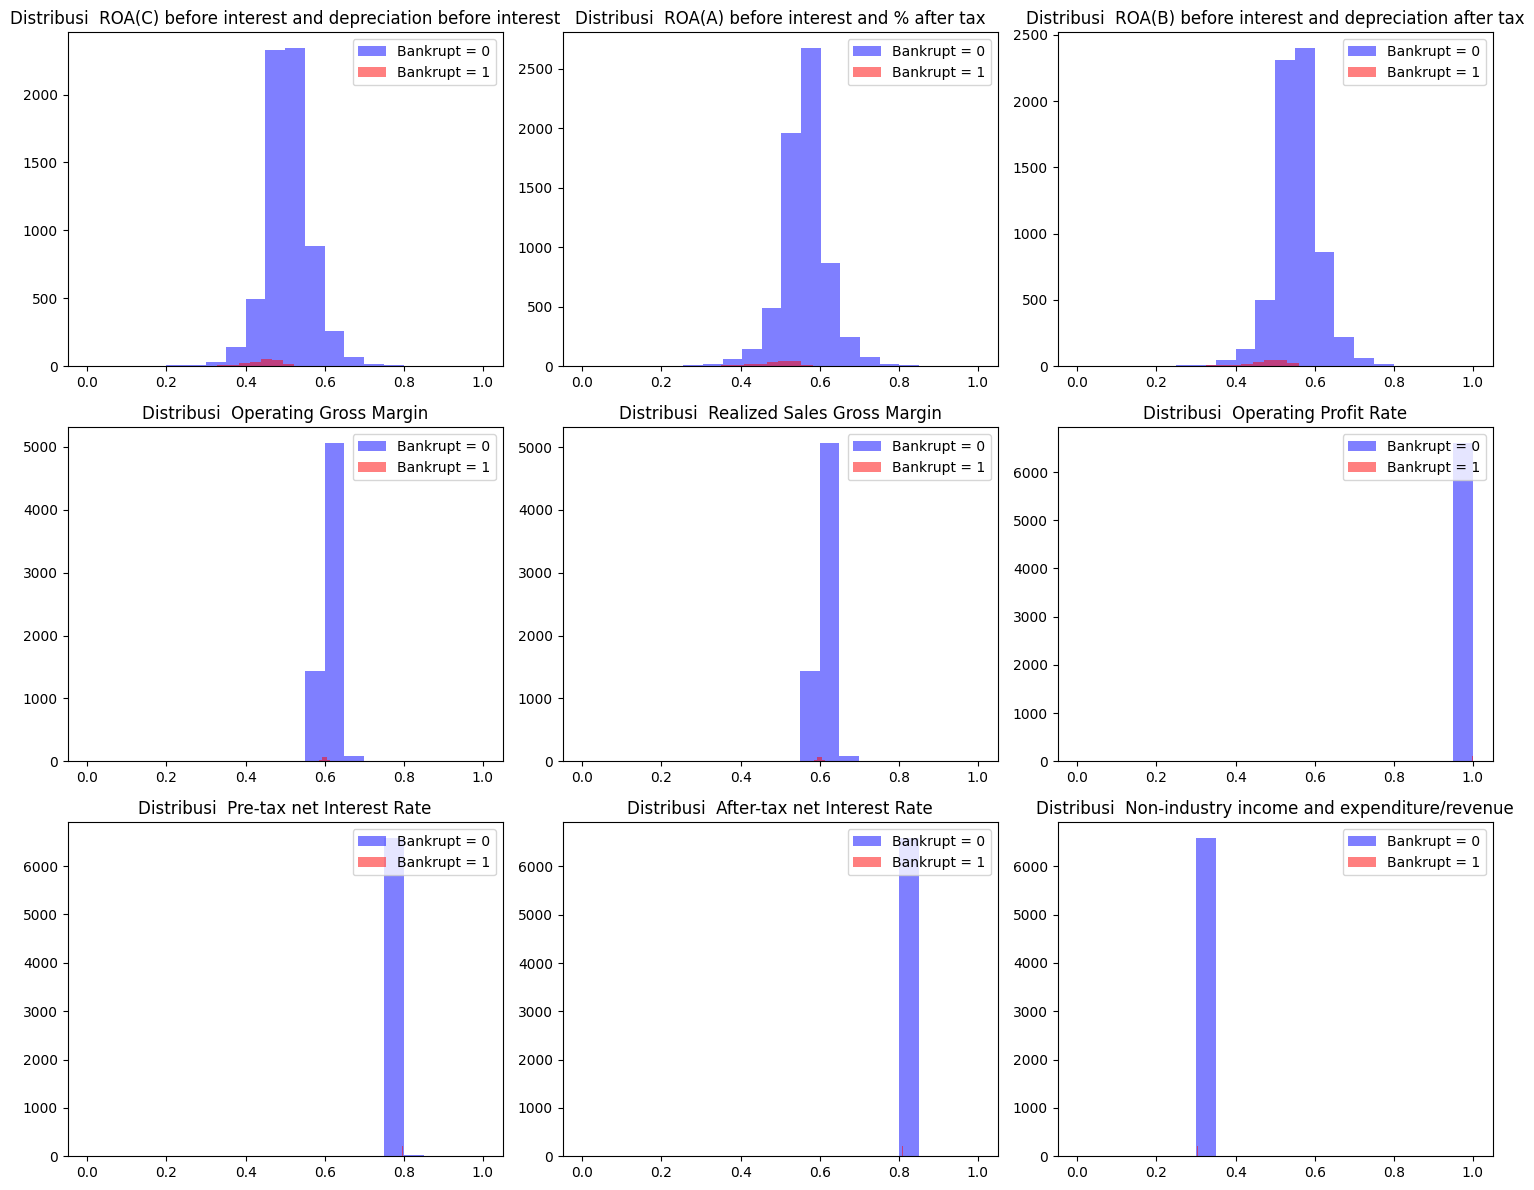

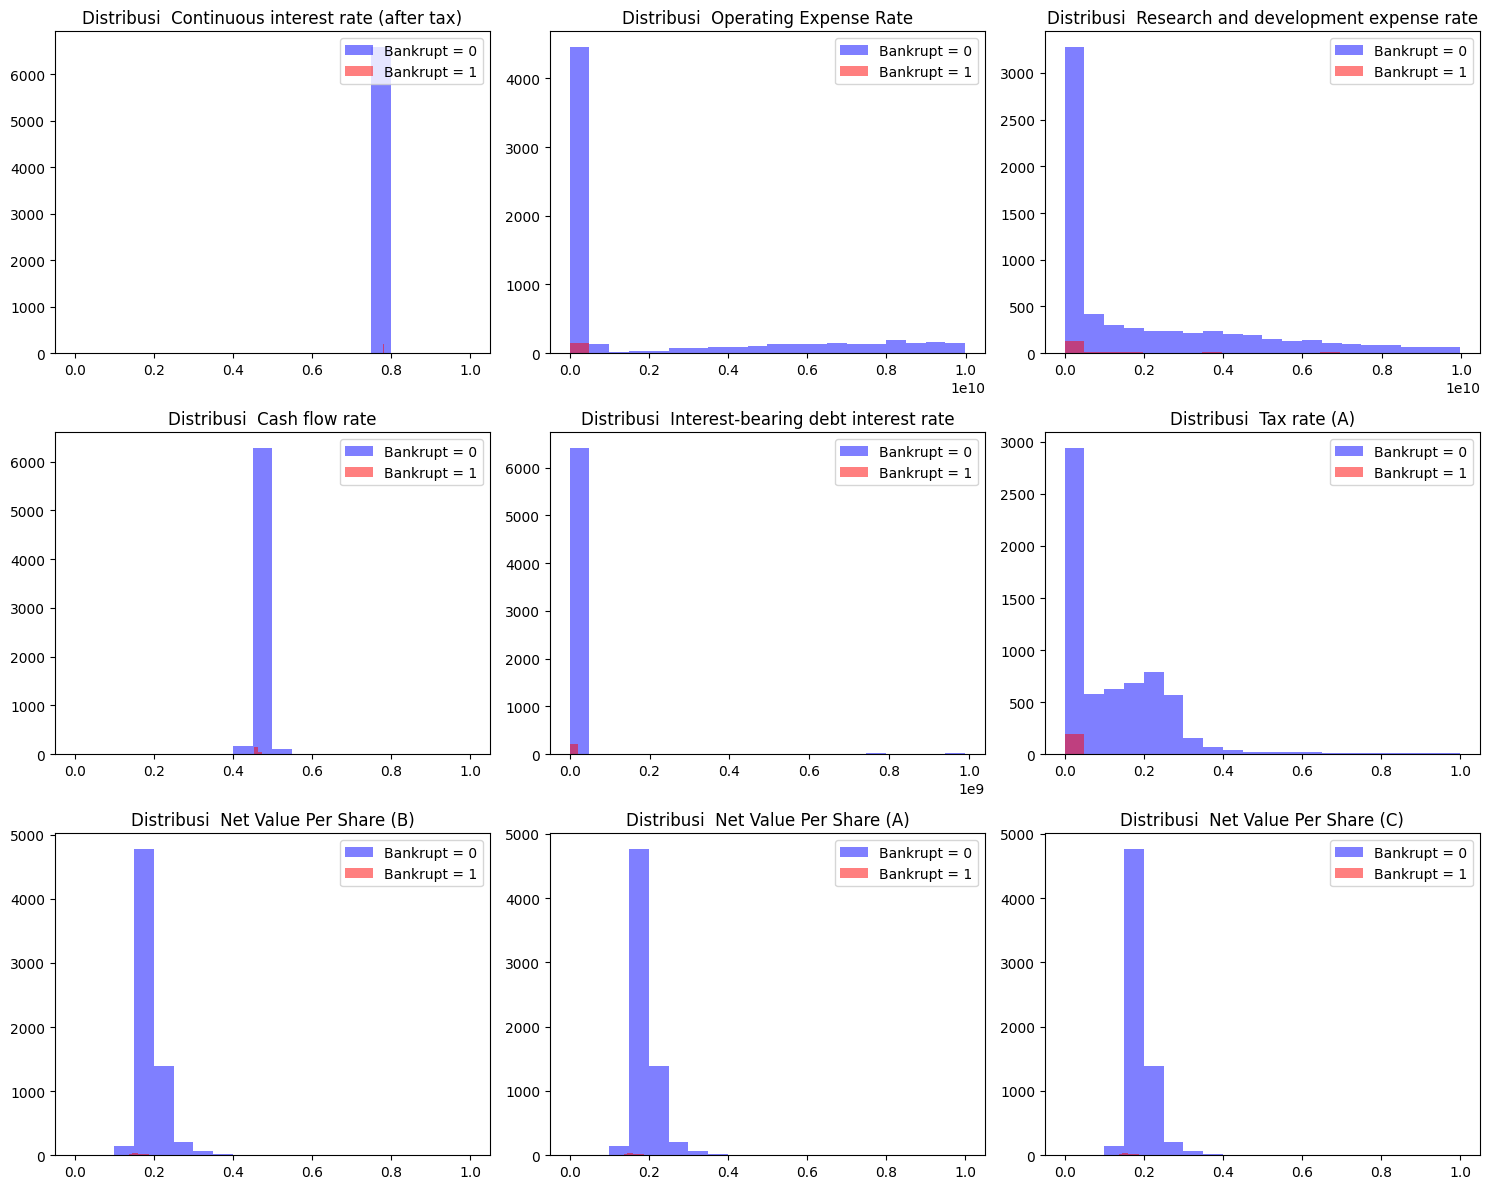

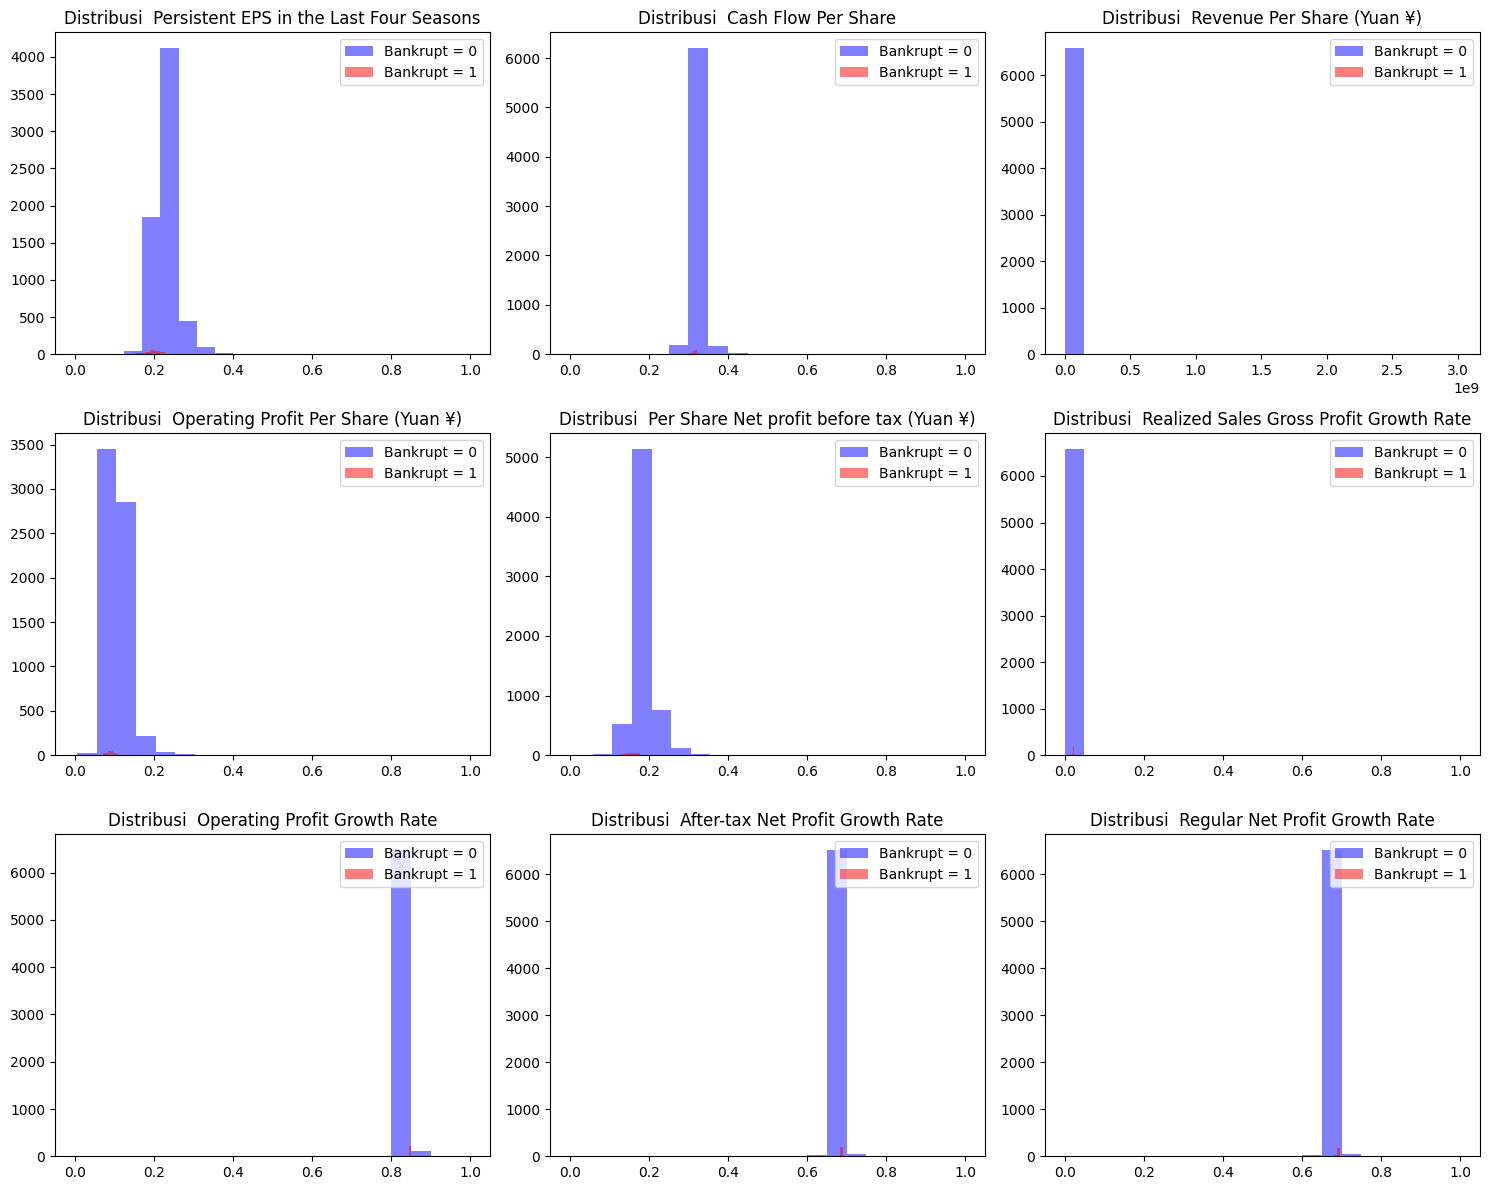

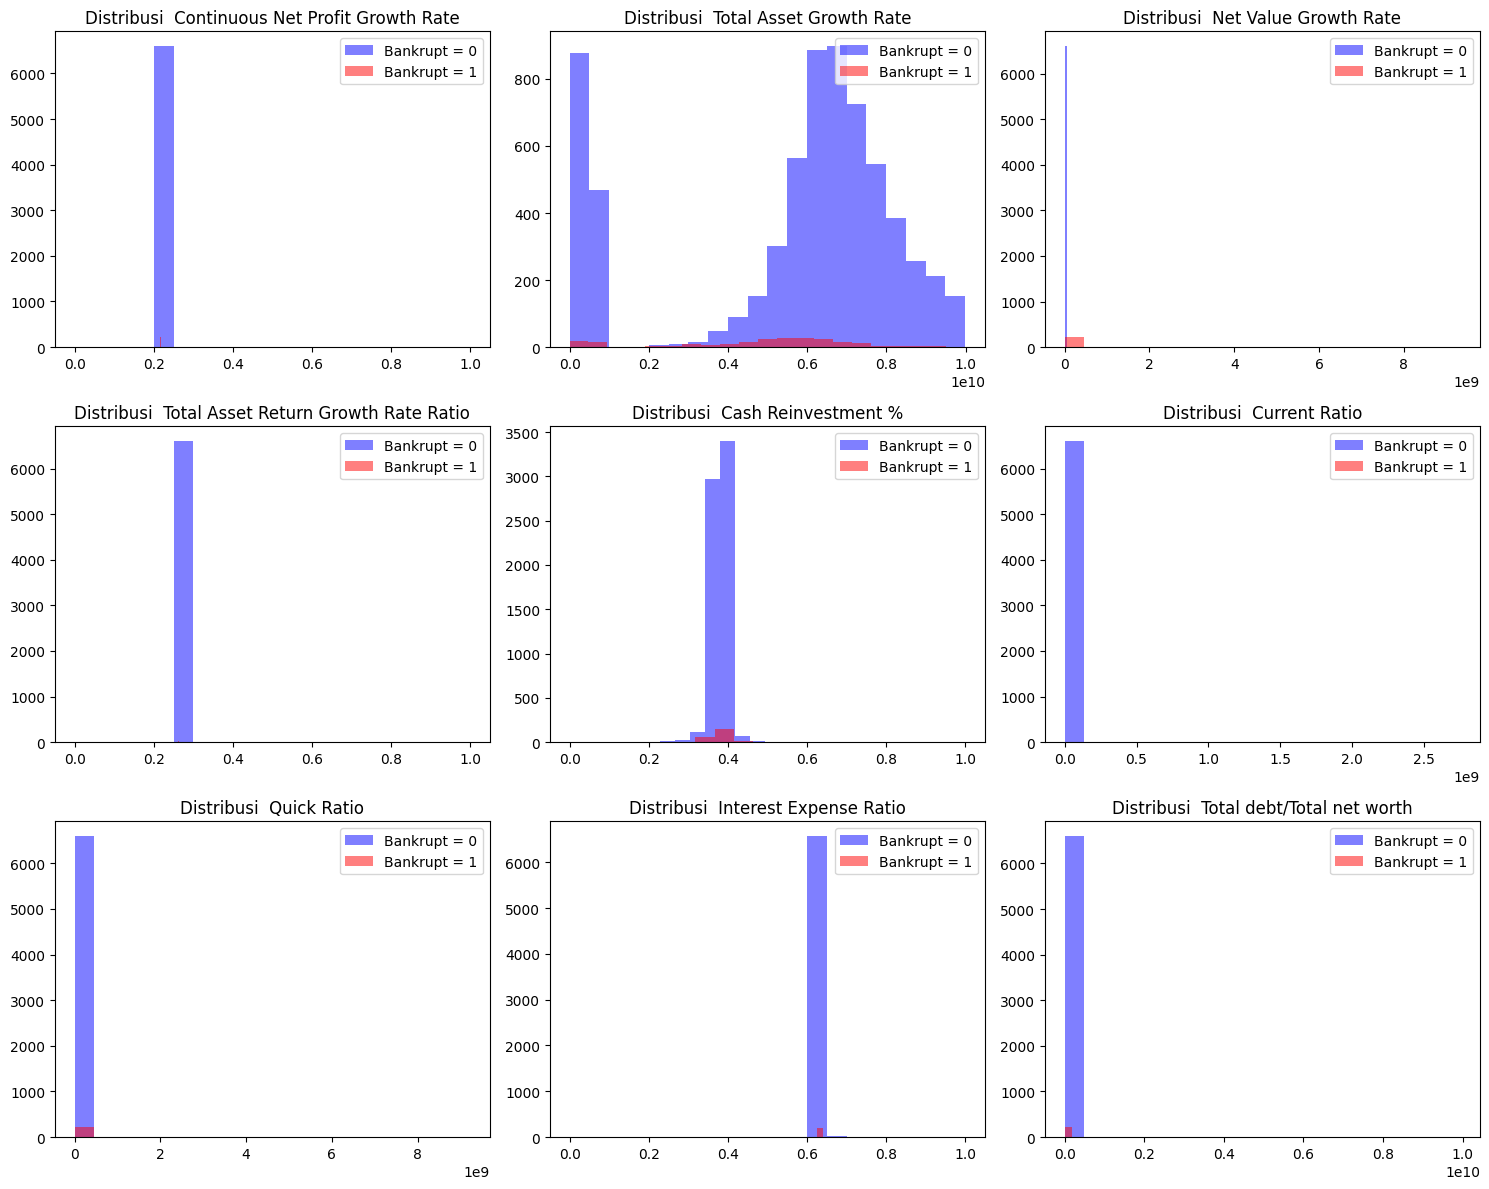

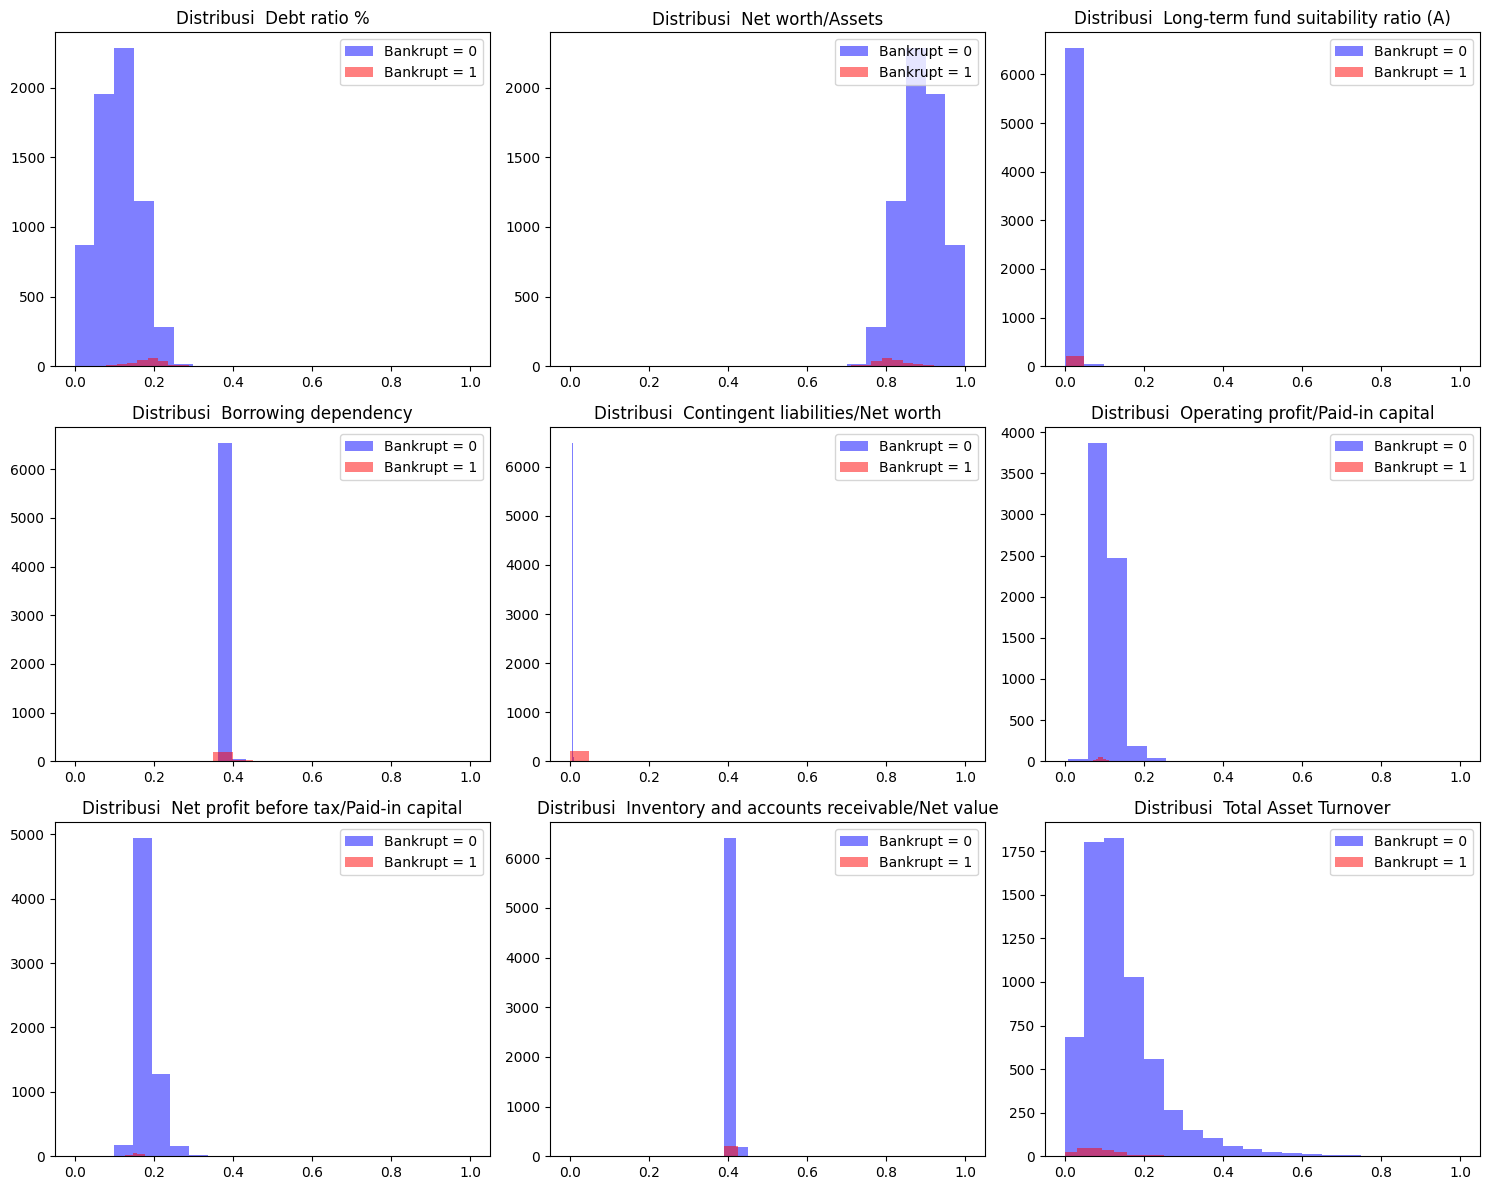

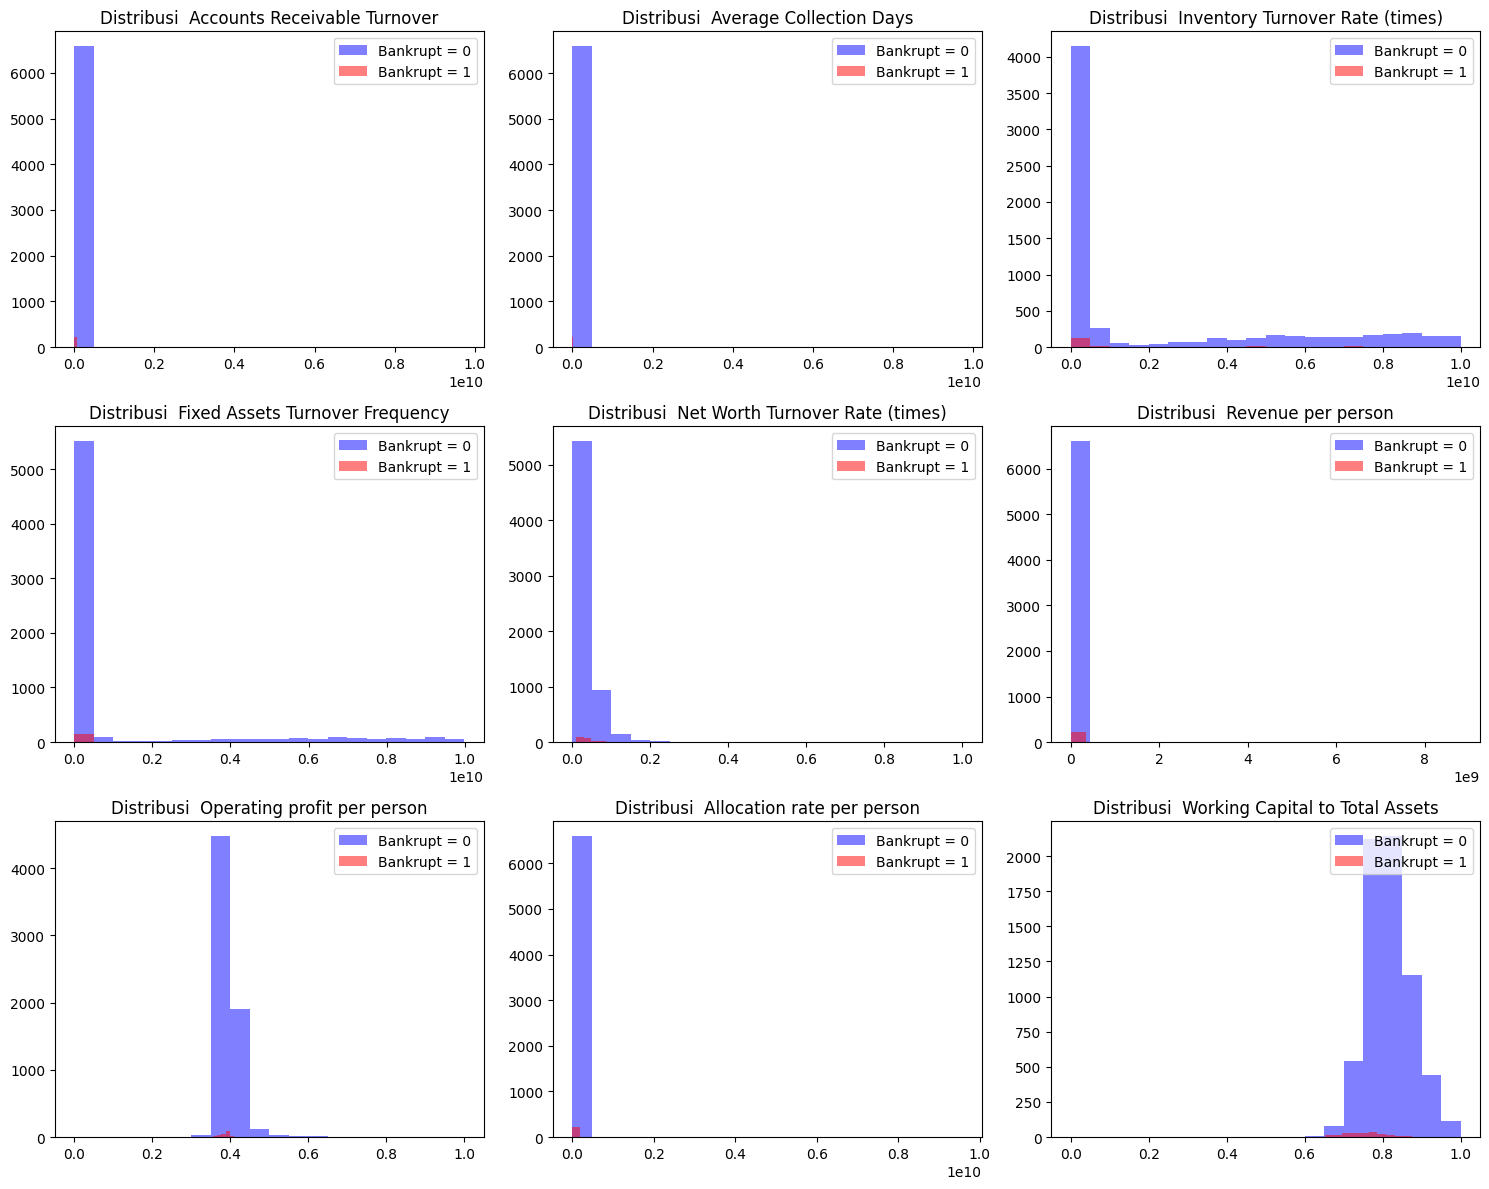

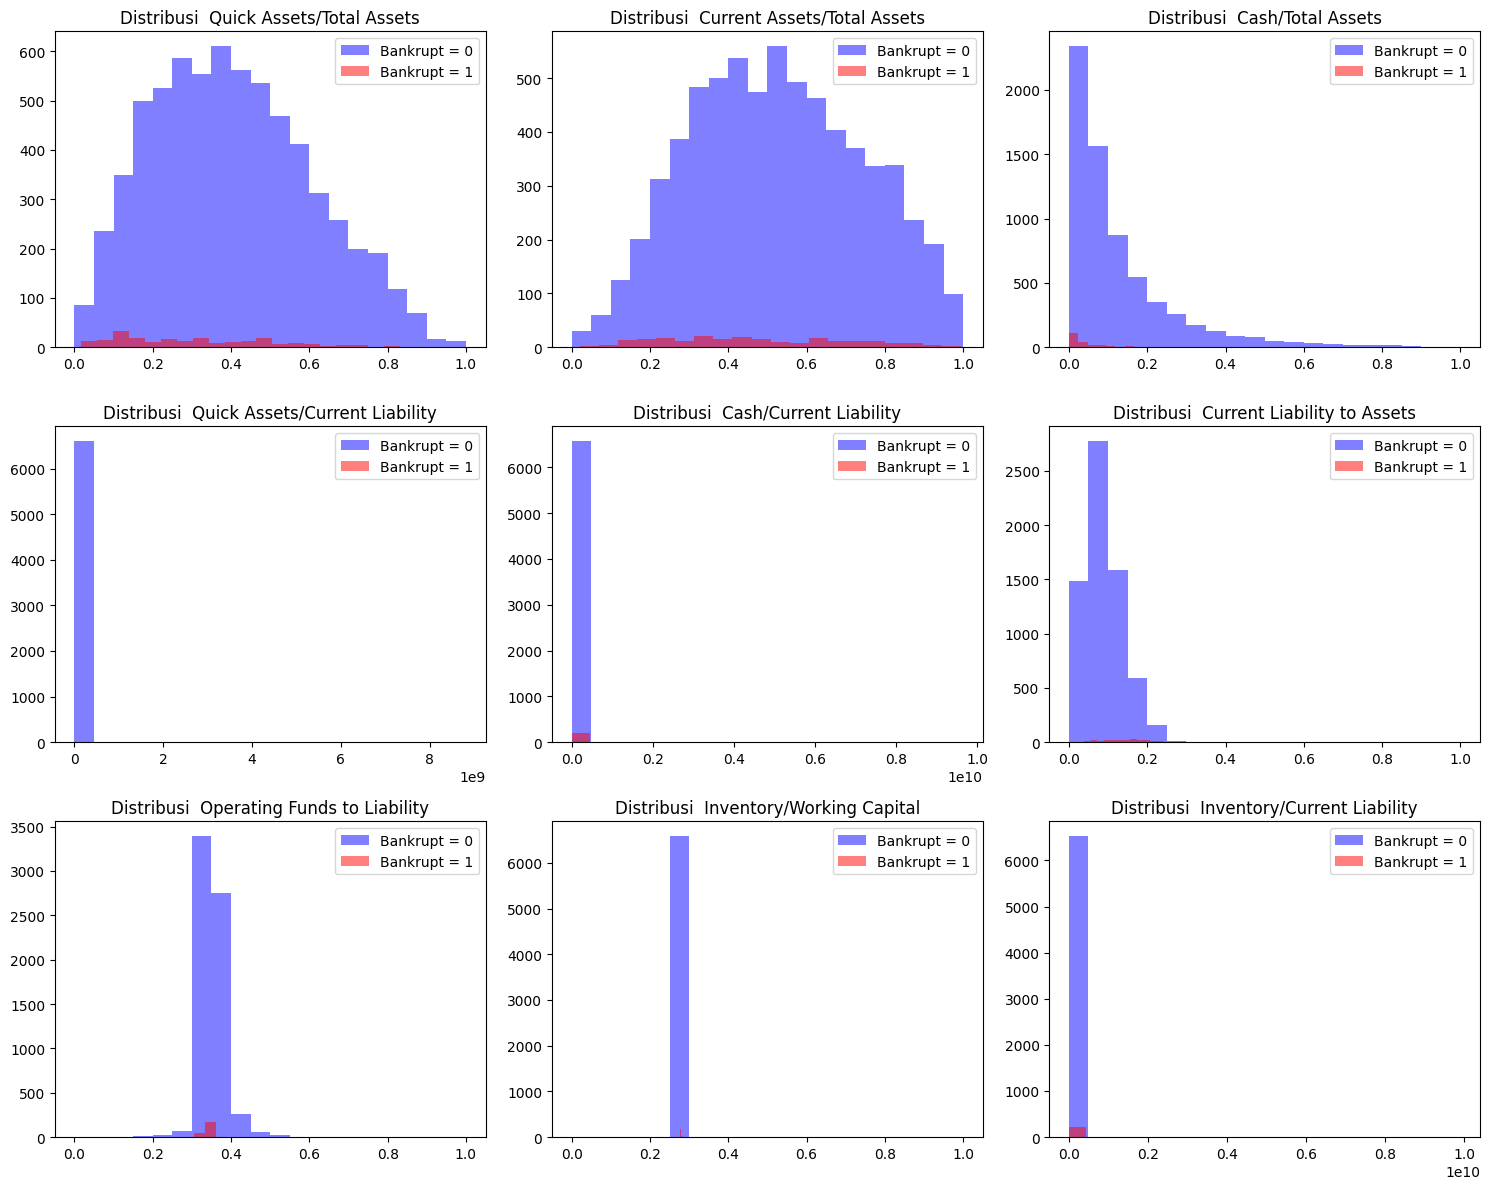

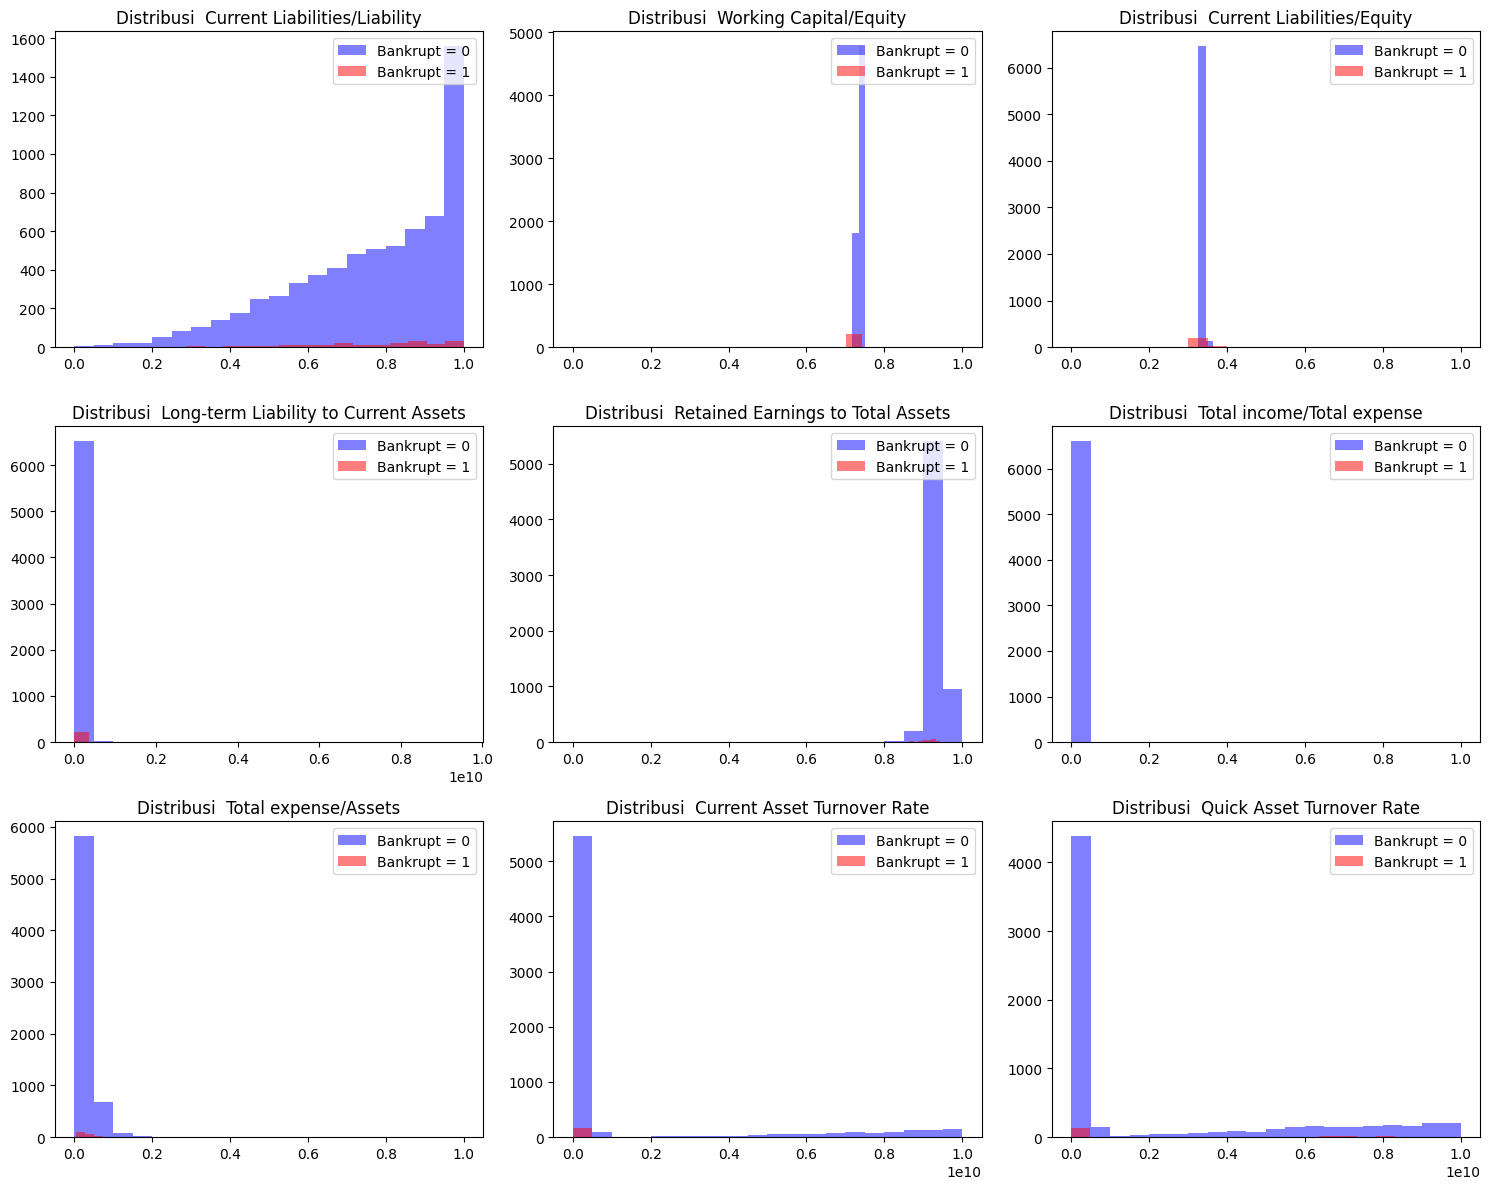

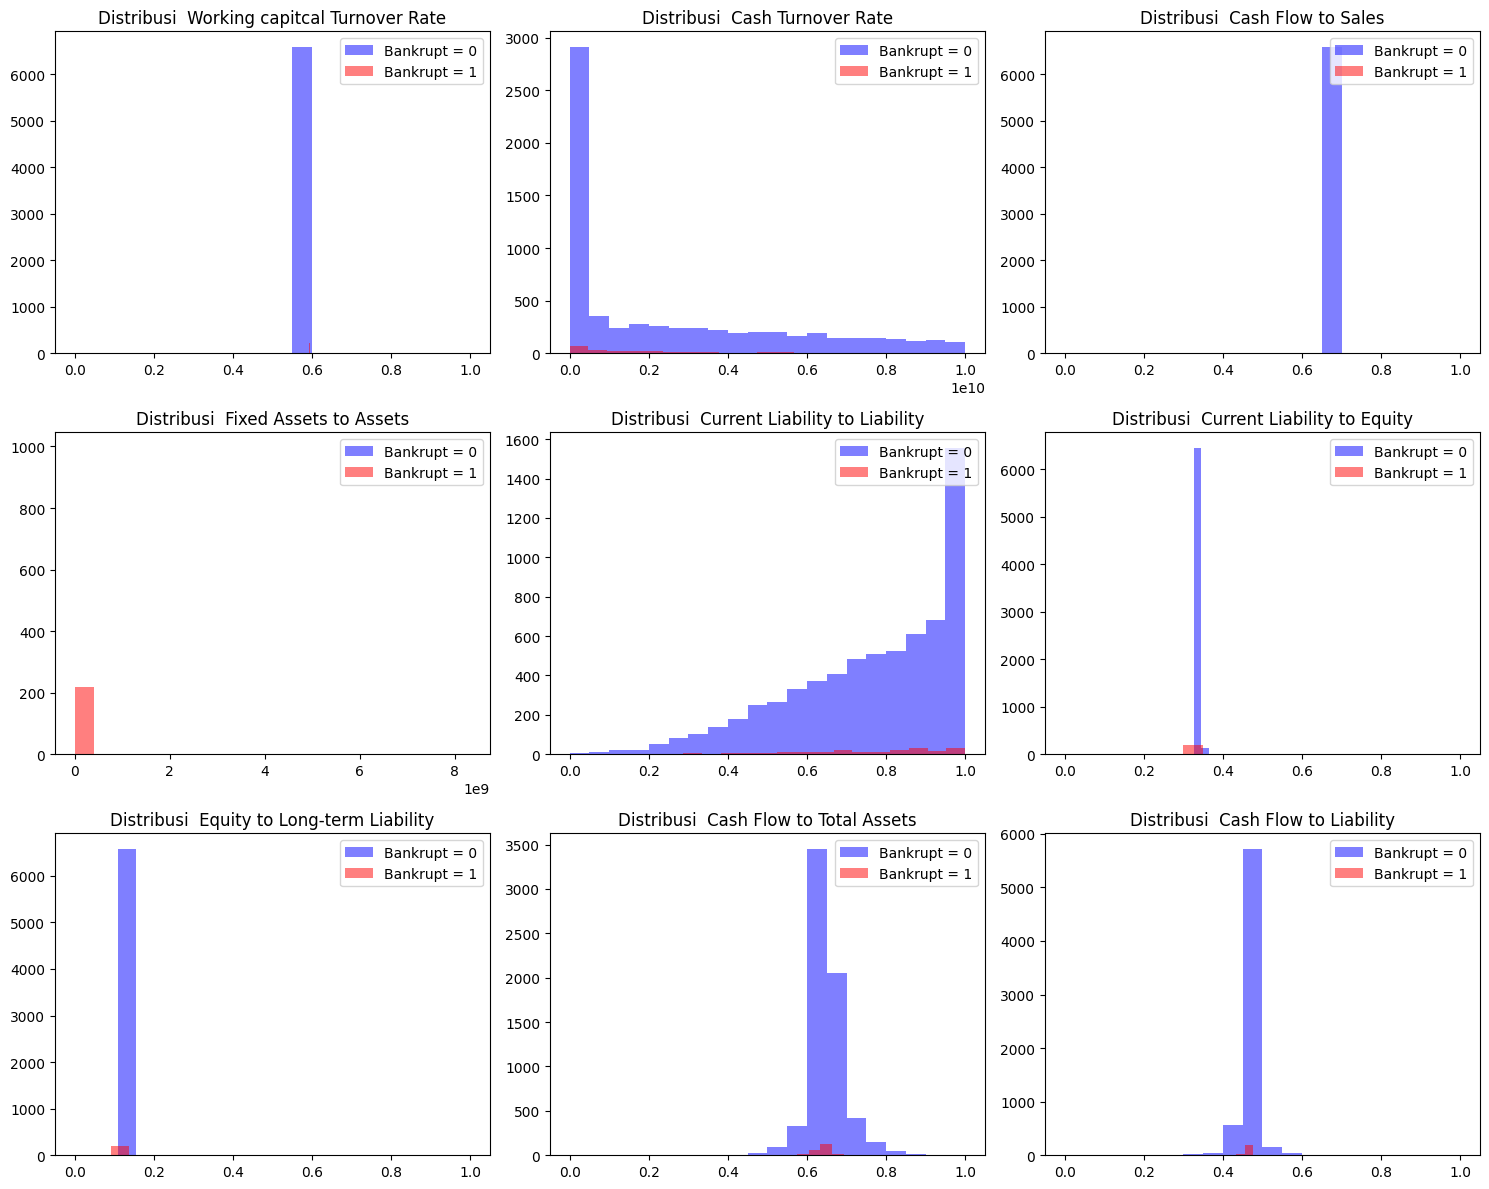

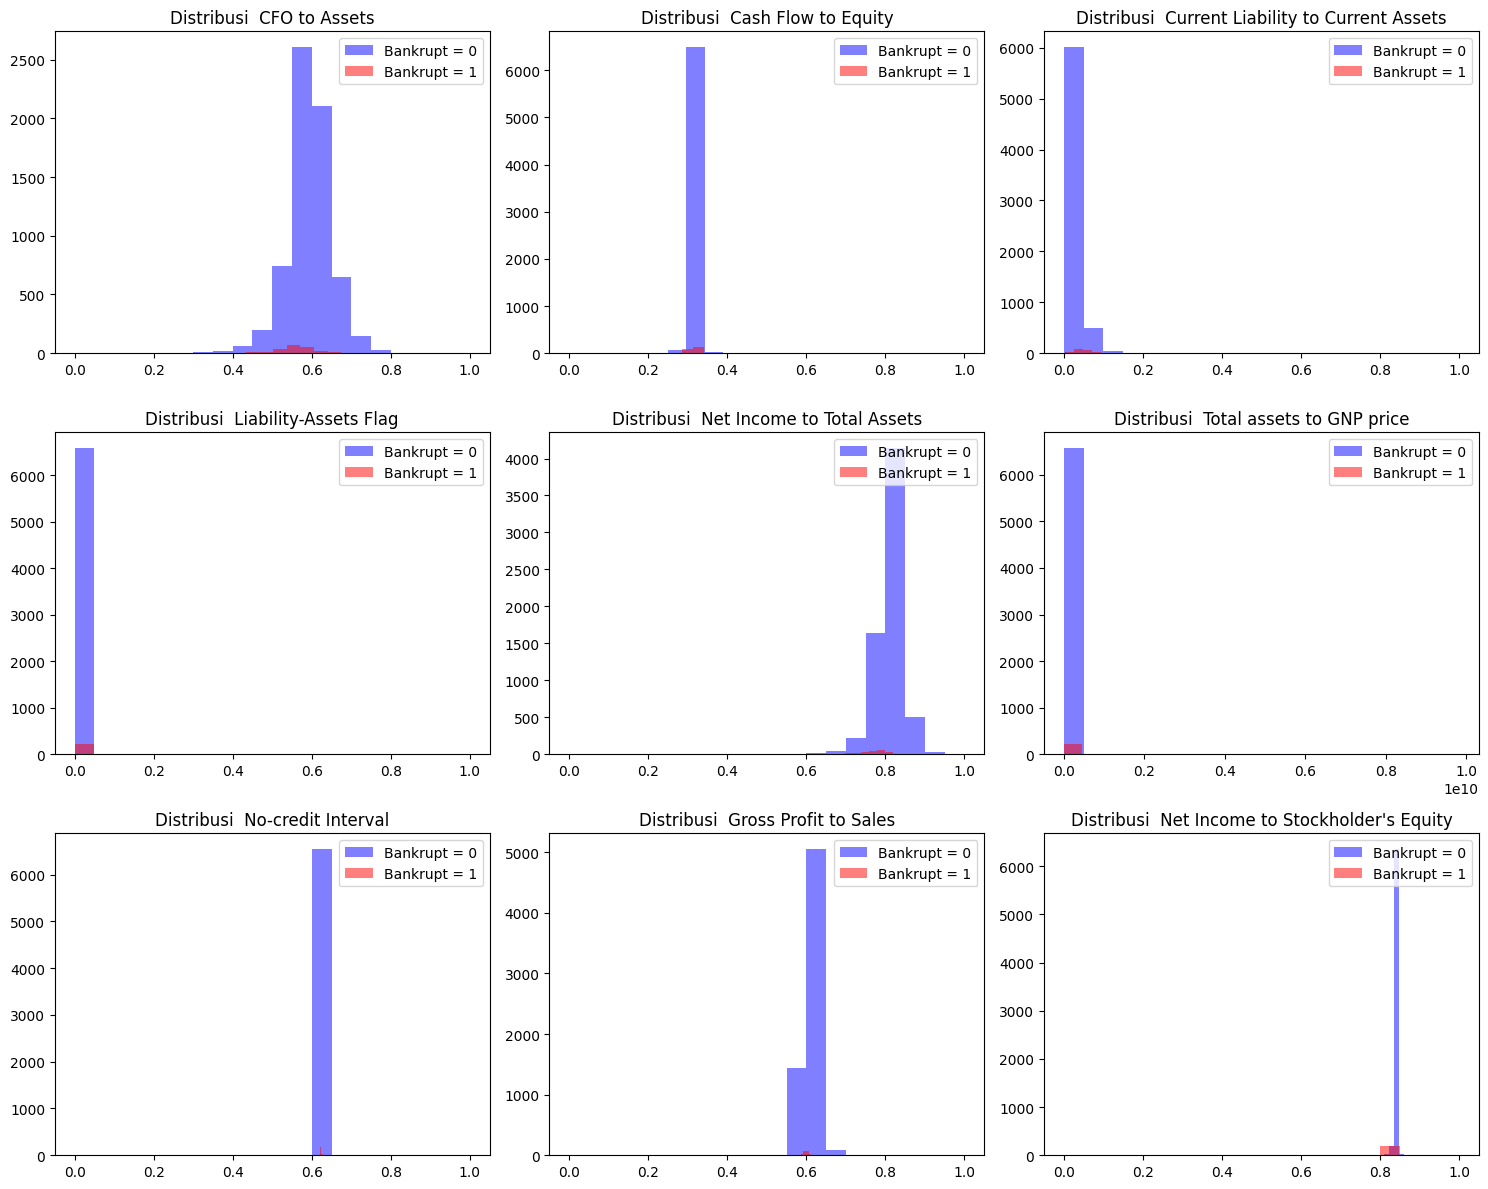

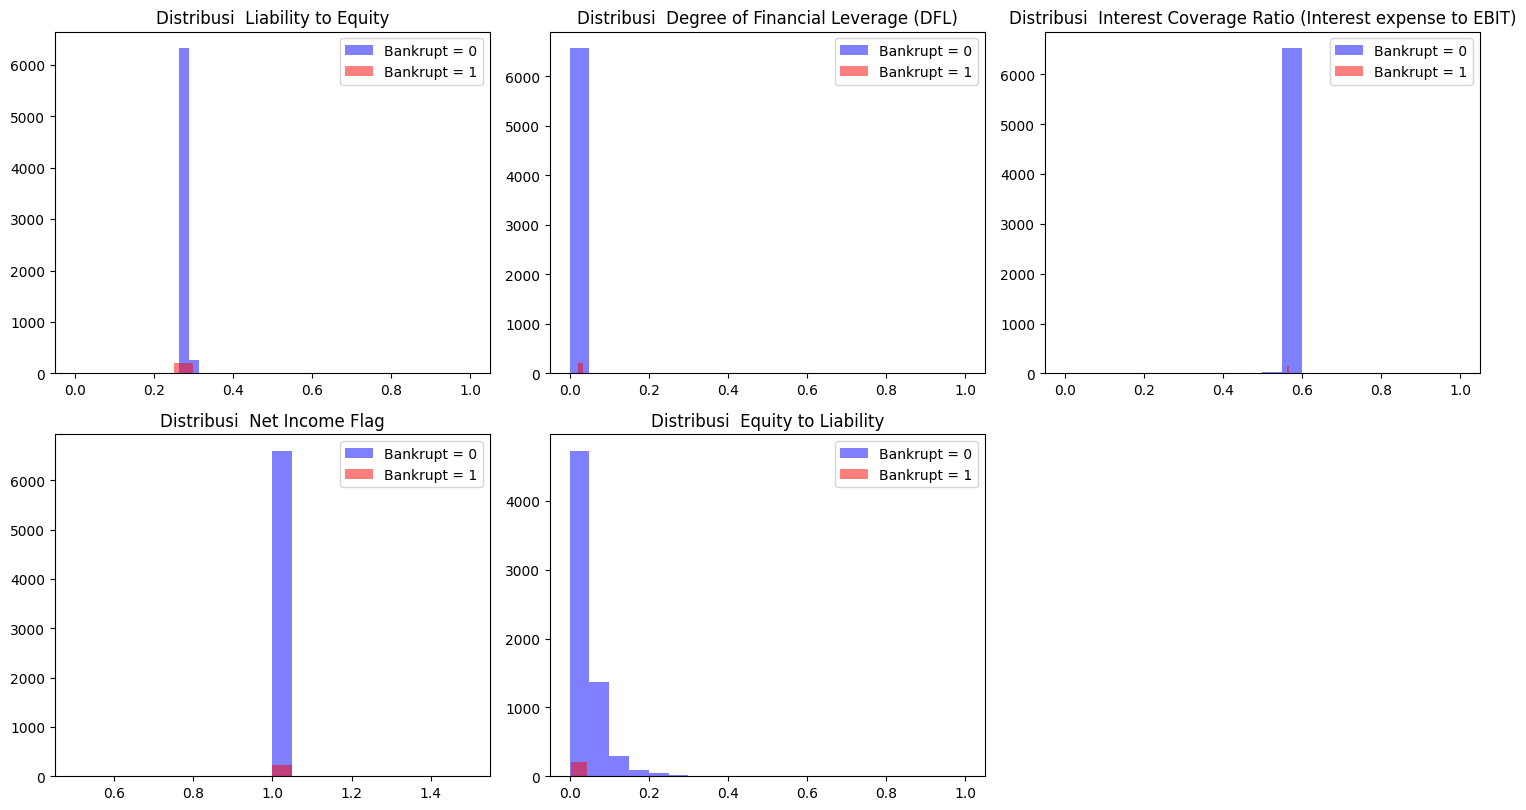

In [ ]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.
feature_cols = [col for col in df.columns if col != 'Bankrupt?']
batch_size = 9

# Pisahkan data sekali di awal agar tidak memfilter df berulang kali di dalam loop
df_0 = df[df['Bankrupt?'] == 0]
df_1 = df[df['Bankrupt?'] == 1]

for i in range(0, len(feature_cols), batch_size):
    batch_features = feature_cols[i:i + batch_size]

    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.flatten()

    for j, col in enumerate(batch_features):
        # Gunakan plt/axes.hist murni (jauh lebih cepat)
        axes[j].hist(df_0[col].dropna(), bins=20, alpha=0.5, label='Bankrupt = 0', color='blue')
        axes[j].hist(df_1[col].dropna(), bins=20, alpha=0.5, label='Bankrupt = 1', color='red')

        axes[j].set_title(f'Distribusi {col}')
        axes[j].legend(loc='upper right')

    # Hapus subplot kosong yang tersisa
    for k in range(len(batch_features), len(axes)):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.show()
    plt.close(fig)

Data mengalami Skewnees dan banyaknya outlier

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

In [ ]:
print("Duplikat:",end=" ")
print(df.duplicated().sum())

Duplikat: 0


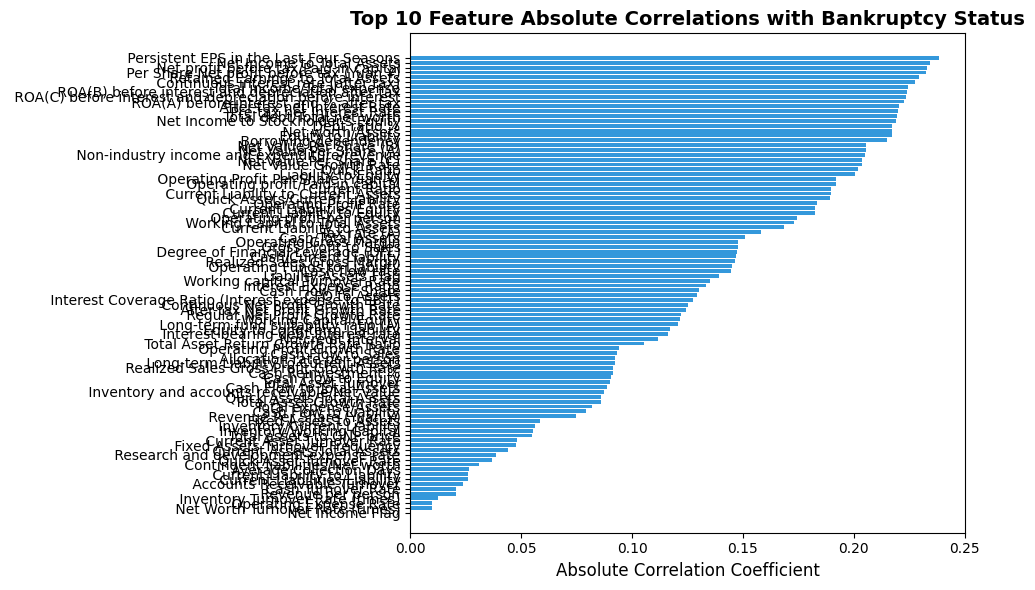

In [ ]:
plt.figure(figsize=(10, 6))
corrs = df.corr(method="spearman")['Bankrupt?'].drop('Bankrupt?').abs().sort_values(ascending=False)#.head(15)
plt.barh(corrs.index[::-1], corrs.values[::-1], color='#3498db')
plt.title('Top 10 Feature Absolute Correlations with Bankruptcy Status', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation Coefficient', fontsize=12)
plt.tight_layout()
plt.show()
# Credit: https://www.kaggle.com/code/abbas829/bankruptancy-eda?scriptVersionId=340161401&cellId=17

Tidak ada fitur yang mendominasi terhadap kebangkrutan($corr>0.5$).

fitur `Net Income Flag` tidak memiliki korelasi apapun

In [ ]:
# Clean column names by removing extra spaces
df.columns = df.columns.str.strip()

df = df.drop(columns=['Net Income Flag'])

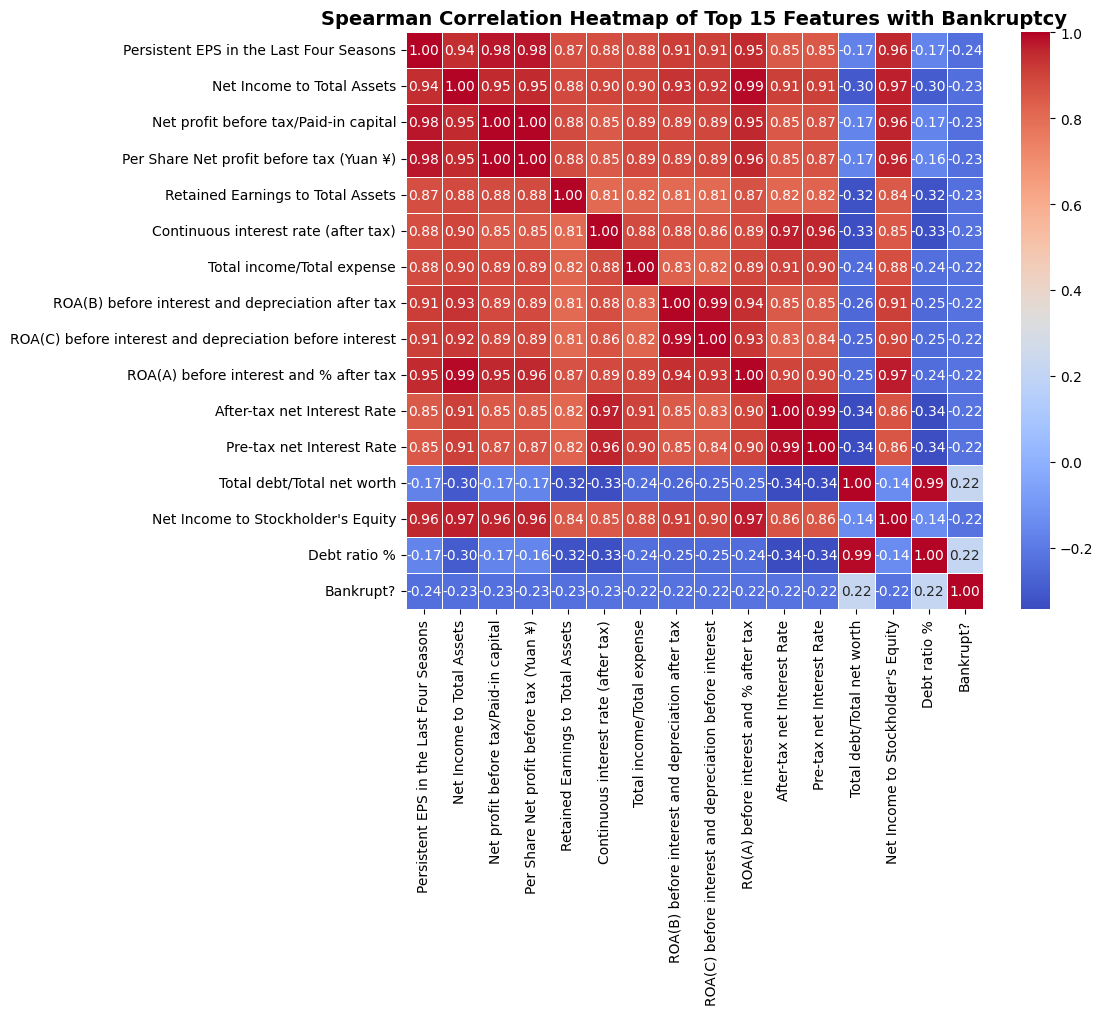

In [ ]:
top_15_features = (
    df.corr(method="spearman")['Bankrupt?']
    .drop('Bankrupt?')
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# 2. Combine the top 15 features with the target column 'Bankrupt?'
selected_cols = list(top_15_features) + ['Bankrupt?']

# 3. Calculate the Spearman correlation matrix for only these columns
top_corr = df[selected_cols].corr(method="spearman")

# 4. Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    top_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title('Spearman Correlation Heatmap of Top 15 Features with Bankruptcy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Terdapat korelasi tinggi antar fitur seperti:
* `Net profit before tax/Paid-in capital `vs.` Per Share Net profit before tax`(1.00)

* `ROA(B)` vs. `ROA(C)`(0.99)

* `Pre-tax net Interest Rate` vs. `After-tax net Interest Rate` (0.99)

* `Total debt/Total net worth` vs. `Debt ratio %` (0.99)

maka perlu dihilangkan

In [ ]:

# 2. Compute the absolute correlation matrix
corr_matrix = df.corr(method="spearman").abs()

# 3. Select the upper triangle of the correlation matrix (excluding diagonal)
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# 4. Identify feature columns where any upper triangle correlation is > 0.9
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]

# 5. Drop the flagged features from the dataset
df_reduced = df.drop(columns=to_drop)

print(f"Original number of features: {len(selected_cols)}")
print(f"Features dropped: {len(to_drop)}")
print(f"Remaining features: {df_reduced.shape[1] - 1}")  # excluding target



Original number of features: 16
Features dropped: 54
Remaining features: 40


Menghapus fitur dengan korelasi yang terlalu tinggi satu sama lainnya

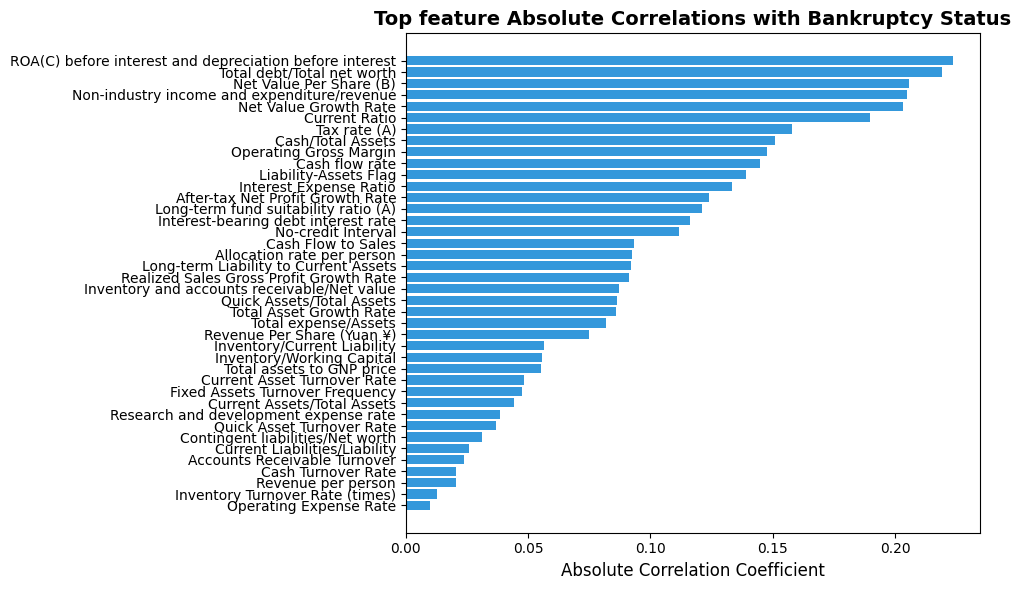

In [ ]:
plt.figure(figsize=(10, 6))
corrs = df_reduced.corr(method="spearman")['Bankrupt?'].drop('Bankrupt?').abs().sort_values(ascending=False)#.head(15)
plt.barh(corrs.index[::-1], corrs.values[::-1], color='#3498db')
plt.title('Top feature Absolute Correlations with Bankruptcy Status', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation Coefficient', fontsize=12)
plt.tight_layout()
plt.show()

Dari 40, ambil 15(termasuk labelnya)

In [ ]:
df_reduced = df_reduced[df_reduced.corr(method="spearman")['Bankrupt?'].abs().sort_values(ascending=False).head(15).index].copy()

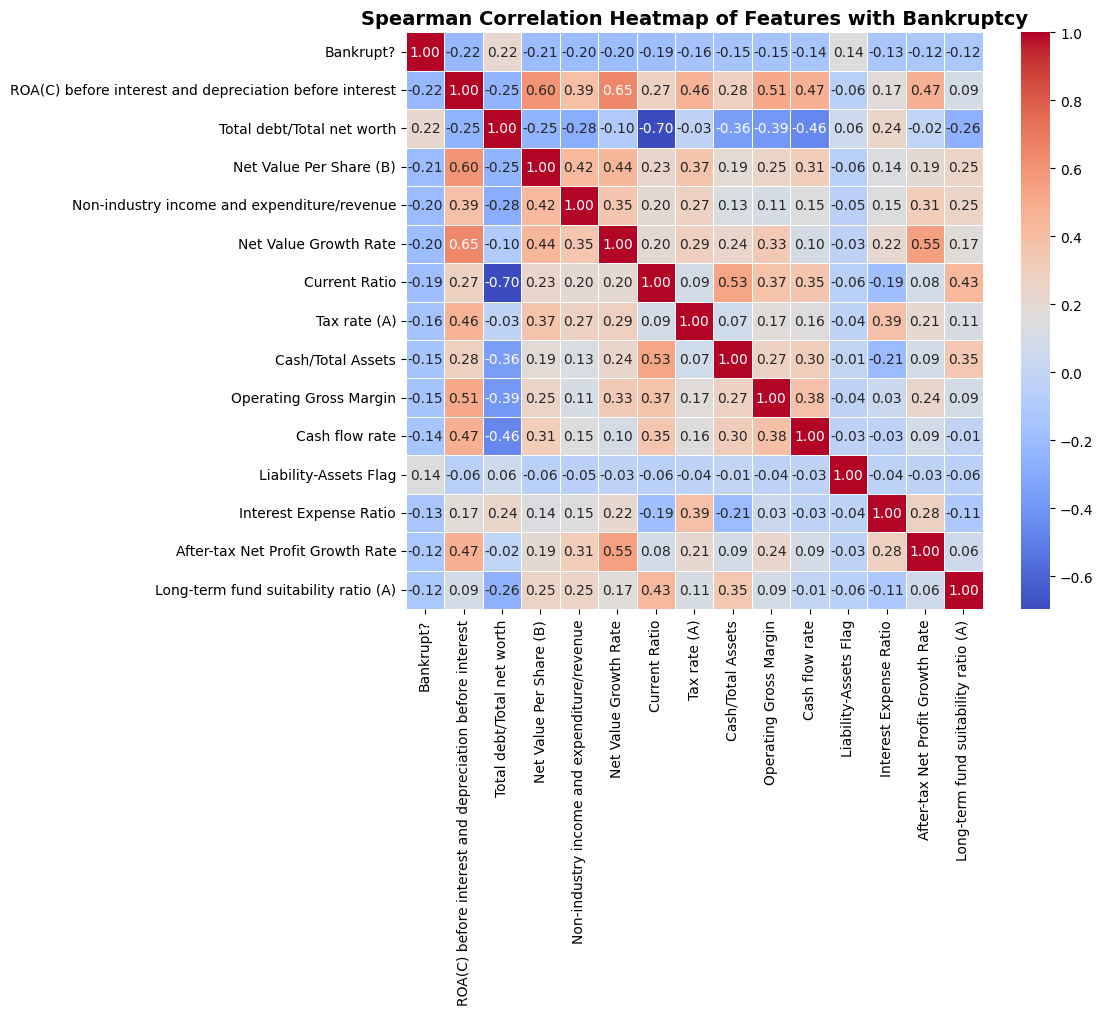

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_reduced.corr(method="spearman"),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title('Spearman Correlation Heatmap of Features with Bankruptcy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [ ]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

#Tidak ada missing value
print("Null?\n",df_reduced.isnull().sum())

Null?
 Bankrupt?                                                  0
ROA(C) before interest and depreciation before interest    0
Total debt/Total net worth                                 0
Net Value Per Share (B)                                    0
Non-industry income and expenditure/revenue                0
Net Value Growth Rate                                      0
Current Ratio                                              0
Tax rate (A)                                               0
Cash/Total Assets                                          0
Operating Gross Margin                                     0
Cash flow rate                                             0
Liability-Assets Flag                                      0
Interest Expense Ratio                                     0
After-tax Net Profit Growth Rate                           0
Long-term fund suitability ratio (A)                       0
dtype: int64


In [ ]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.
# Columns stored as object or category dtypes
cat_cols = df_reduced.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = df_reduced.select_dtypes(include=['number']).columns.tolist()

print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: []
Numeric: ['Bankrupt?', 'ROA(C) before interest and depreciation before interest', 'Total debt/Total net worth', 'Net Value Per Share (B)', 'Non-industry income and expenditure/revenue', 'Net Value Growth Rate', 'Current Ratio', 'Tax rate (A)', 'Cash/Total Assets', 'Operating Gross Margin', 'Cash flow rate', 'Liability-Assets Flag', 'Interest Expense Ratio', 'After-tax Net Profit Growth Rate', 'Long-term fund suitability ratio (A)']


In [ ]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df_reduced.drop(columns=['Bankrupt?'])
y = df_reduced['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

In [ ]:
# Menyimpan seluruh hasil model
prd = []

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [ ]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.
gini = DecisionTreeClassifier(criterion='gini', random_state=42)
gini.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
predict = gini.predict(X_test)
train_acc = gini.score(X_train,y_train)
test_acc = gini.score(X_test,y_test)
f1 = f1_score(y_test,predict)
prec = precision_score(y_test, predict)
rec = recall_score(y_test, predict)
prd.append(
    {
        'split': 'gini',
        'depth': gini.get_depth(),
        'y_pred': predict,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'f1_score':f1,
        'precision':prec,
        'recall':rec
    }
)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [ ]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.
entp = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=gini.get_depth())
entp.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=14, random_state=42)

In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
predict = entp.predict(X_test)
train_acc = entp.score(X_train,y_train)
test_acc = entp.score(X_test,y_test)
f1 = f1_score(y_test,predict)
prec = precision_score(y_test, predict)
rec = recall_score(y_test, predict)
prd.append(
    {
        'split': 'entropy',
        'depth': entp.get_depth(),
        'y_pred': predict,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'f1_score':f1,
        'precision':prec,
        'recall':rec
    }
)

In [ ]:
print(prd)

[{'split': 'gini', 'depth': 14, 'y_pred': array([0, 0, 0, ..., 0, 0, 0]), 'train_acc': 1.0, 'test_acc': 0.9552785923753666, 'f1_score': 0.26506024096385544, 'precision': 0.28205128205128205, 'recall': 0.25}, {'split': 'entropy', 'depth': 14, 'y_pred': array([0, 0, 0, ..., 0, 0, 0]), 'train_acc': 0.9998166819431714, 'test_acc': 0.9523460410557185, 'f1_score': 0.2857142857142857, 'precision': 0.2765957446808511, 'recall': 0.29545454545454547}]


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [ ]:
tst_ovf = []

In [ ]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

In [ ]:
for i in range(1,20):
  model = DecisionTreeClassifier(criterion='gini',max_depth=i,random_state=42)
  model.fit(X_train,y_train)
  predict = model.predict(X_test)
  train_acc = model.score(X_train,y_train)
  test_acc = model.score(X_test,y_test)
  f1= f1_score(y_test,predict)
  tst_ovf.append(
    {
        'split': 'gini',
        'max_depth': i,
        'y_pred':predict,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'f1':f1
    }
  )

In [ ]:
print(tst_ovf)

[{'split': 'gini', 'max_depth': 1, 'y_pred': array([0, 0, 0, ..., 0, 0, 0]), 'train_acc': 0.9677360219981668, 'test_acc': 0.967741935483871, 'f1': 0.0}, {'split': 'gini', 'max_depth': 2, 'y_pred': array([0, 0, 0, ..., 0, 0, 0]), 'train_acc': 0.96993583868011, 'test_acc': 0.9699413489736071, 'f1': 0.16326530612244897}, {'split': 'gini', 'max_depth': 3, 'y_pred': array([0, 0, 0, ..., 0, 0, 0]), 'train_acc': 0.9721356553620532, 'test_acc': 0.9736070381231672, 'f1': 0.3076923076923077}, {'split': 'gini', 'max_depth': 4, 'y_pred': array([0, 0, 0, ..., 0, 0, 0]), 'train_acc': 0.9723189734188817, 'test_acc': 0.9721407624633431, 'f1': 0.24}, {'split': 'gini', 'max_depth': 5, 'y_pred': array([0, 0, 0, ..., 0, 0, 0]), 'train_acc': 0.974518790100825, 'test_acc': 0.969208211143695, 'f1': 0.43243243243243246}, {'split': 'gini', 'max_depth': 6, 'y_pred': array([0, 0, 0, ..., 0, 0, 1]), 'train_acc': 0.9769019248395967, 'test_acc': 0.967008797653959, 'f1': 0.26229508196721313}, {'split': 'gini', 'max_

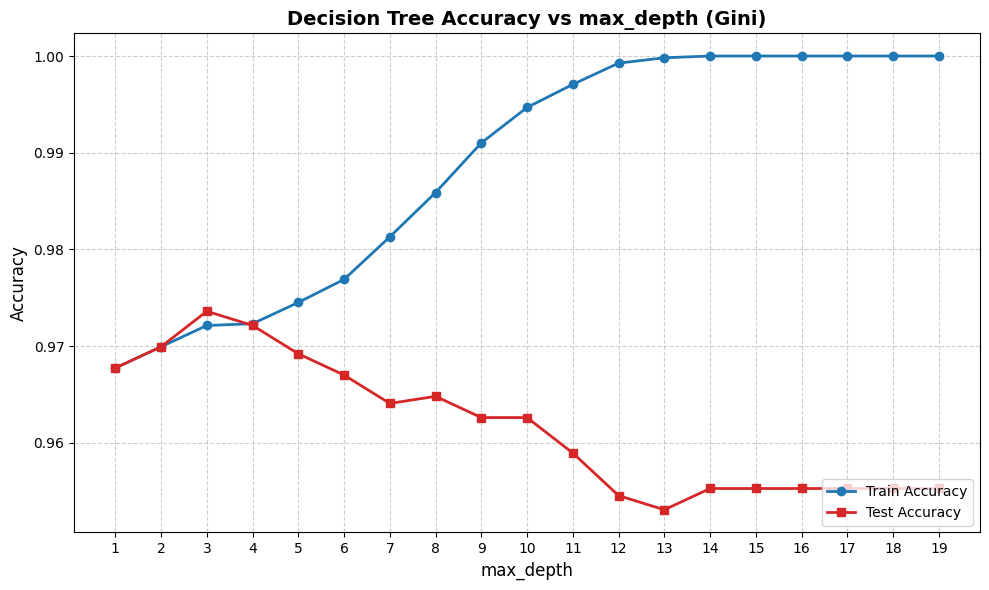

In [ ]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).


# Convert collected metrics list into a DataFrame
df_ovf = pd.DataFrame(tst_ovf)

# Separate numeric depths (1-19) from None (unconstrained tree) for linear x-axis plotting
df_numeric = df_ovf[df_ovf['max_depth'].notnull()].sort_values(by='max_depth')

plt.figure(figsize=(10, 6))

# Plot Training vs Testing Accuracy
plt.plot(
    df_numeric['max_depth'],
    df_numeric['train_acc'],
    marker='o',
    color='tab:blue',
    linewidth=2,
    label='Train Accuracy',
)
plt.plot(
    df_numeric['max_depth'],
    df_numeric['test_acc'],
    marker='s',
    color='tab:red',
    linewidth=2,
    label='Test Accuracy',
)

plt.title(
    'Decision Tree Accuracy vs max_depth (Gini)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(df_numeric['max_depth'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

Terlihat bahwa model mengalami overfitting pada depth $>3$. Titik paling optimal adalah ketika $depth = 3$

# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

for i in prd:
  print("Split:", i['split'])
  print("Depth:", i['depth'],"(Default)")
  print("Train Accuracy:", i['train_acc'])
  print("Test Accuracy:", i['test_acc'])
  print("F1 Score:", i['f1_score'])
  print()

evl = pd.DataFrame(prd)
evl = evl.drop(columns=['y_pred'])
evl.set_index('split',inplace=True)
evl.T

Split: gini
Depth: 14 (Default)
Train Accuracy: 1.0
Test Accuracy: 0.9552785923753666
F1 Score: 0.26506024096385544

Split: entropy
Depth: 14 (Default)
Train Accuracy: 0.9998166819431714
Test Accuracy: 0.9523460410557185
F1 Score: 0.2857142857142857



split,gini,entropy
depth,14.000000,14.000000
train_acc,1.000000,0.999817
test_acc,0.955279,0.952346
f1_score,0.265060,0.285714
precision,0.282051,0.276596
recall,0.250000,0.295455


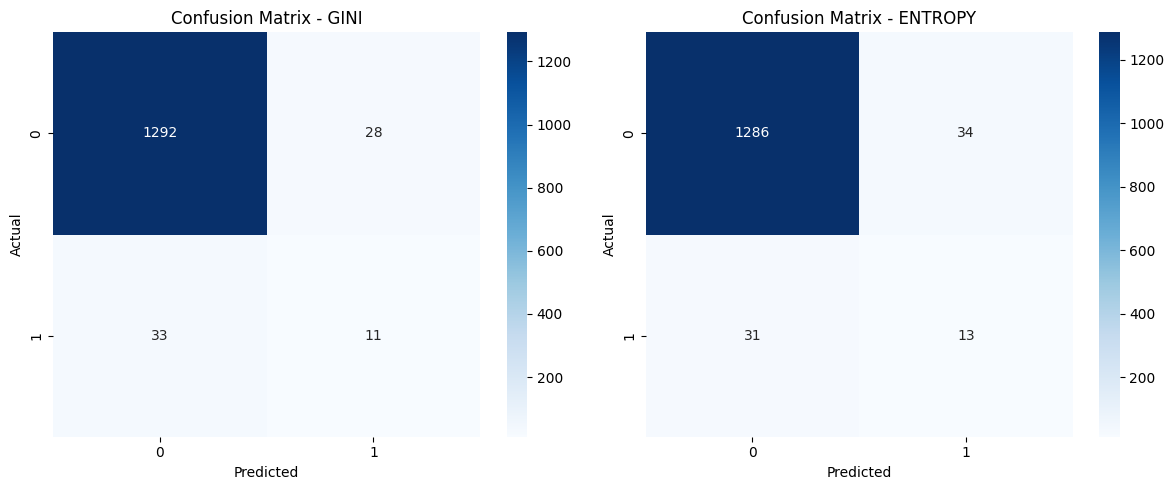

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, split in enumerate(['gini', 'entropy']):
  # Mengambil y_pred sesuai split (aman meskipun urutan prd tertukar)
  y_pred = next(item['y_pred'] for item in prd if item['split'] == split)

  cm = confusion_matrix(y_test, y_pred)

  # Menggunakan axes[i]
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
  axes[i].set_title(f'Confusion Matrix - {split.upper()}')
  axes[i].set_xlabel('Predicted')
  axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Model terbaik: GINI (Test Acc: 0.9553)


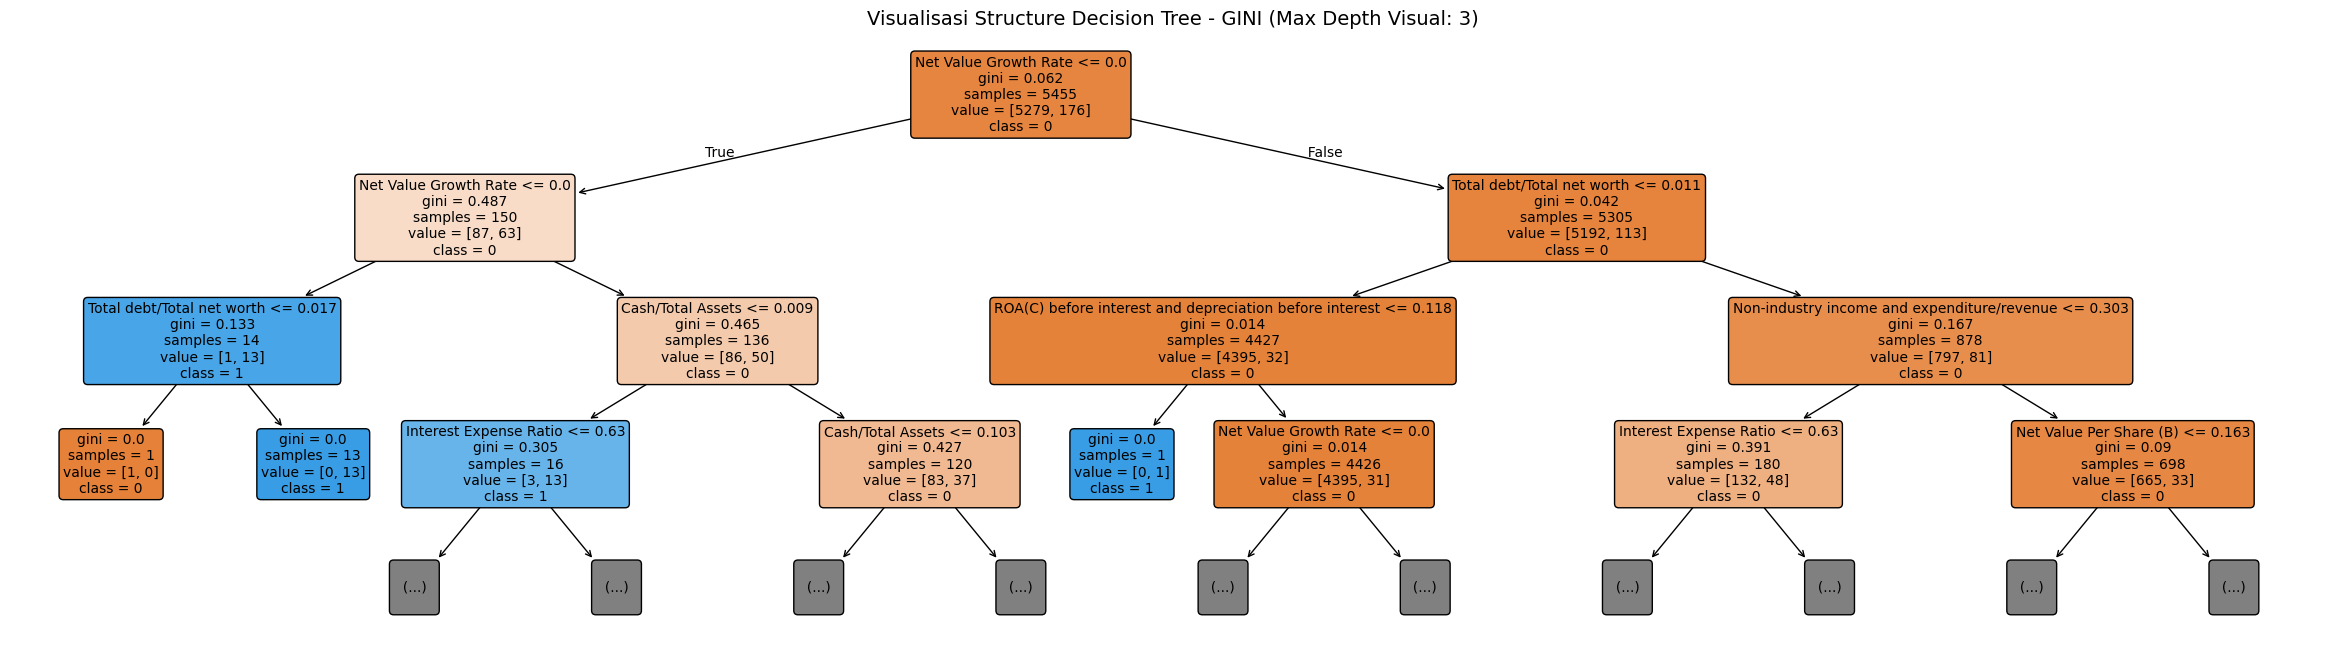

In [ ]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.
best_run = max(prd, key=lambda x: x['test_acc'])
best_split = best_run['split']
best_model = entp if best_split == 'entropy' else gini
print(f"Model terbaik: {best_split.upper()} (Test Acc: {best_run['test_acc']:.4f})")

plt.figure(figsize=(30, 8))
plot_tree(
    best_model,
    max_depth=3,                            # Membatasi kedalaman agar tetap terbaca
    feature_names=X_train.columns,          # Sesuaikan jika berupa numpy array (misal: X.columns)
    class_names=[str(c) for c in best_model.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f"Visualisasi Structure Decision Tree - {best_split.upper()} (Max Depth Visual: 3)", fontsize=14)
plt.show()

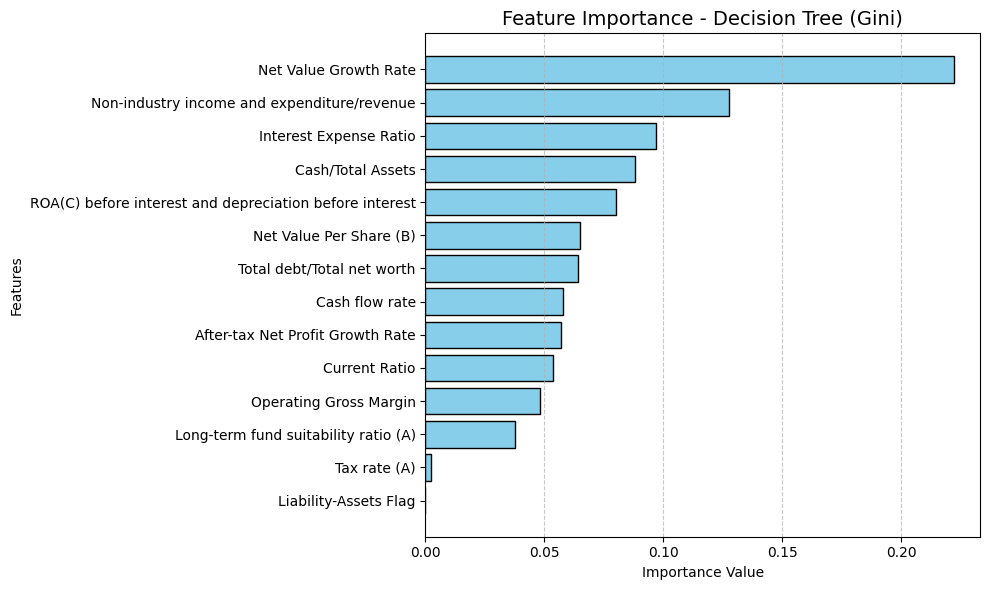

In [ ]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gini.feature_importances_
}).sort_values(by='Importance', ascending=True)  # Urutkan ascending agar fitur teratas berada di posisi paling atas pada chart

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue', edgecolor='black')

plt.title('Feature Importance - Decision Tree (Gini)', fontsize=14)
plt.xlabel('Importance Value')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

`Net Value Growth Rate` adalah fitur yang paling penting walaupun secara korelasi spearman posisinya dibawah fitur lain seperti `ROA(C) before interest and depreciation before interest`, `Total debt/Total net worth`, dan `Net Value Per Share (B)`

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.


## 5.1 Temuan Exploratory Data Analysis (EDA)

Proses *Exploratory Data Analysis* (EDA) memberikan fondasi krusial sebelum tahap pelatihan model Decision Tree:

1. **Kelas Target (`Bankrupt?`) Imbalance Ekstrem:** Dari total 6.819 baris data, sebanyak 6.599 perusahaan ($96{,}8\%$) berstatus tidak bangkrut (`Bankrupt = 0`) dan hanya 220 perusahaan ($3{,}2\%$) yang mengalami kebangkrutan. Imbalans kelas yang sangat ekstrem ini menyebabkan metrik Akurasi menjadi bias. Model sederhana yang selalu memprediksi status "sehat" dapat mencapai akurasi $96{,}8\%$, namun gagal total dalam mendeteksi kebangkrutan. Oleh karena itu, evaluasi model wajib berpatokan pada metrik **Precision**, **Recall**, dan **F1-Score**.
2. **Penggunaan Korelasi Rank Spearman:** Distribusi rasio keuangan pada dataset ini menunjukkan *skewness* berat, penumpukan nilai, serta *extreme outliers*. Korelasi Pearson kurang tepat karena mengasumsikan distribusi bivariat normal dan hubungan linier murni. Korelasi Spearman mengonversi nilai mentah menjadi peringkat (*ordinal ranks*), sehingga membatasi dampak outlier ekstrem dan mengukur hubungan monotonik secara obyektif.

---

## 5.2 Perbandingan Kriteria Split: Gini Impurity vs. Entropy

Eksperimen dilakukan untuk membandingkan dua kriteria *splitter* utama pada Decision Tree tanpa batasan kedalaman awal:

| Metrik Evaluasi | Gini Impurity | Entropy (Info Gain) | Selisih / Keterangan |
| :--- | :---: | :---: | :--- |
| **Train Accuracy** | $100{,}0\%$ | $99{,}98\%$ | Gini mencapai pemisahan sempurna pada data latih |
| **Test Accuracy** | **$95{,}53\%$** | $95{,}23\%$ | Gini unggul tipis $+0{,}30\%$ |
| **Precision** | **$28{,}21\%$** | $27{,}66\%$ | Gini sedikit lebih tahan terhadap *False Positive* |
| **Recall** | $25{,}00\%$ | **$29{,}55\%$** | Entropy mendeteksi lebih banyak kelas bangkrut (13 vs 11) |
| **F1-Score** | $26{,}51\%$ | **$28{,}57\%$** | Entropy unggul $+2{,}06\%$ pada keseimbangan Precision-Recall |

### Analisis Temuan:
1. **Performa Keseluruhan yang Mirip:** Hasil antara Gini dan Entropy tidak berbeda secara signifikan. Hal ini wajar karena secara matematis, fungsi *Gini Impurity* $G = 1 - \sum p_i^2$ dan *Entropy* $H = -\sum p_i \log_2 p_i$ memiliki kurva cembung yang sangat serupa dalam mengukur heterogenitas node.
2. **Komputasi vs. Sensitivitas:** Gini cenderung bekerja lebih cepat secara komputasi karena tidak melibatkan kalkulasi logaritma. Namun, Entropy sedikit lebih sensitif terhadap perubahan probabilitas kecil pada sampel minoritas, sehingga menghasilkan *Recall* yang sedikit lebih tinggi ($29{,}55\%$ vs $25{,}00\%$) pada kasus kebangkrutan ini.
3. **Kendala Imbalance:** Kedua kriteria sama-sama menghasilkan F1-Score yang sangat rendah ($< 30\%$). Hal ini membuktikan bahwa mengganti kriteria split saja **tidak cukup** untuk mengatasi masalah *class imbalance* yang ekstrem.

---

## 5.3 Analisis Regularisasi (`max_depth`) dan Gejala Overfitting

Untuk mengamati pengaruh hiperparameter `max_depth` terhadap *generalization error*, dilakukan eksperimen variasi kedalaman pohon dari $1$ hingga $19$ menggunakan kriteria Gini.

### Identifikasi Gejala Overfitting:
1. **Titik Depth 3 - 5:**
   * Onset *Overfitting* mulai terlihat jelas pada **$\text{max_depth} \ge 4$**.
   * Pada **$\text{max_depth} = 3$**, model mencapai Test Accuracy tertinggi ($97{,}36\%$) dengan perbandingan *Train Acc* ($97{,}21\%$) dan *Test Acc* ($97{,}36\%$) yang sangat seimbang.
   * Pada max_depth = 5, model mencapai F1-Score tertinggi ($43{,}24\%$) sebelum akhirnya menurun drastis.
2. **Titik Depth $> 5$:**
   * Ketika $\text{max_depth}$ ditingkatkan dari $5$ ke $14$, *Train Accuracy* terus melejit naik hingga $100{,}0\%$.  Sebaliknya, *Test Accuracy* justru merosot secara konsisten dari $97{,}36\%$ turun ke $95{,}53\%$.
3. **Penyebab:**
   Tanpa pembatasan kedalaman, pohon keputusan membuat aturan split yang sangat spesifik (*deep leaf nodes*) hanya untuk mengakomodasi beberapa sampel *outlier* atau *noise* pada data *training*. Akibatnya, model kehilangan kemampuan generalisasi saat diuji pada data *testing*.

---

## 5.4 Analisis Feature Importance

Berdasarkan model Decision Tree terbaik, derajat kepentingan fitur (*Feature Importance*) dihitung berdasarkan total pengurangan *Gini Impurity* yang disumbangkan oleh masing-masing fitur (Gini Importance):

1. **Top Feature — `Net Value Growth Rate` ($\approx 0{,}22$ / $22\%$):**
   Menjadi kontributor terbesar dalam setiap keputusan *splitting* awal pohon.
2. **Fitur Pendukung Utama:**
   * `Non-industry income and expenditure/revenue` ($\approx 0{,}13$)
   * `Interest Expense Ratio` ($\approx 0{,}10$)
   * `Cash/Total Assets` ($\approx 0{,}09$)
   * `ROA(C) before interest and depreciation before interest` ($\approx 0{,}08$)

### Korelasi vs Feature Importance:
Terdapat temuan menarik di mana `Net Value Growth Rate` memiliki koefisien korelasi Spearman yang lebih rendah terhadap target dibanding `ROA(C)` atau `Total debt/Total net worth`.

Hal tersebut terjadi karena korelasi Spearman hanya mengukur hubungan monotonik tunggal antara satu fitur dengan target. Sementara itu, Decision Tree mampu menangkap interaksi non-linier kompleks antar variabel. Sebuah fitur dengan korelasi linier/rank sedang dapat memberikan *Information Gain* yang sangat tinggi ketika dikombinasikan secara kondisional dengan fitur lain pada *sub-node* tertentu.

---

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

## 6.1 Kesimpulan

 Berdasarkan eksperimen klasifikasi kebangkrutan perusahaan menggunakan Decision Tree, dapat disimpulkan bahwa:

1. **Dampak Imbalance Data:** Ketimpangan kelas target yang ekstrem ($96{,}8\%$ vs $3{,}2\%$) membuat metrik akurasi menjadi tidak relevan. Model *default* tampak berkinerja baik dengan akurasi $95{,}5\%$, namun F1-Score sesungguhnya sangat rendah ($26{,}5\% - 28{,}5\%$) karena banyaknya kasus kebangkrutan yang gagal terdeteksi (*False Negative* tinggi).
2. **Gini vs Entropy:** Kedua kriteria split memberikan performa yang relatif setara. Gini sedikit lebih unggul pada akurasi keseluruhan, sedangkan Entropy sedikit lebih baik dalam merecall kelas minoritas (kebangkrutan).
3. **Pentingnya Regularisasi:** Tanpa pembatasan `max_depth`, Decision Tree mengalami *overfitting* parah (Akurasi latih $100\%$ vs Akurasi uji $95{,}5\%$). Pengaturan regularisasi optimal berada pada $\text{max_depth} = 3$ hingga $5$, yang berhasil menahan *overfitting* sekaligus meningkatkan F1-Score hingga $43{,}24\%$.
4. **Indikator Kebangkrutan Utama:** Rasio pertumbuhan nilai bersih (`Net Value Growth Rate`) dan pendapatan non-industri (`Non-industry income and expenditure/revenue`) merupakan dua indikator finansial paling dominan dalam memprediksi risiko kebangkrutan.

---

## 6.2 Saran

Untuk pengembangan dan peningkatan performa model pada eksperimen selanjutnya, disarankan beberapa langkah berikut:

1. **Penerapan Teknik Balancing Data (SMOTE):**
   Saran utama untuk mengatasi *class imbalance* ekstrem ini adalah menerapkan algoritma resampling seperti SMOTE (Synthetic Minority Over-sampling Technique) atau ADASYN pada data *training*. Dengan menduplikasi sampel sintetis kelas bangkrut, model Decision Tree akan terdorong untuk mempelajari pola kebangkrutan secara lebih mendalam tanpa bias terhadap kelas mayoritas.
2. **Penerapan Cost-Sensitive Learning:**
   Menggunakan parameter `class_weight='balanced'` pada `DecisionTreeClassifier` untuk memberikan penalti atau bobot error yang lebih tinggi apabila model salah memprediksi perusahaan yang sebenarnya bangkrut.
